# ***Practica 2 MAD1 2026***

**Alumno: Martín Godoy**

**Universidad Nacional del Sur**

---

---

## ***Importamos librerías***


In [28]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

np.random.seed(42)

---

---

## ***Creamos el dataset***

Crearemos un dataset sintético, con algunos errores hechos a propósito con el fin de hacer un análisis exploratorio, posterior corrección de errores y demás.

In [7]:
n = 1000

#Creamos el dataset
df = pd.DataFrame({
    "edad_cliente": np.random.normal(35, 12, n).astype(int),
    "precio_unitario": np.random.normal(5000, 2000, n),
    "cantidad": np.random.randint(1, 8, n),
    "descuento": np.random.uniform(0, 0.4, n)
})

#Creamos la variable total_venta que es el resultado de multiplicar el precio unitario por la cantidad y restarle el descuento aplicado
df["total_venta"] = df["precio_unitario"] * df["cantidad"] * (1 - df["descuento"])

### **Introducimos errores intencionales**


In [8]:
#Edades fuera de rango
df.loc[np.random.choice(df.index, 10), "edad_cliente"] = 150
df.loc[np.random.choice(df.index, 5), "edad_cliente"] = -3

#Precios negativos
df.loc[np.random.choice(df.index, 8), "precio_unitario"] = -500

#Cantidad 0
df.loc[np.random.choice(df.index, 10), "cantidad"] = 0

#Descuentos fuera de rango
df.loc[np.random.choice(df.index, 5), "descuento"] = 1.5

#Valores faltantes
df.loc[np.random.choice(df.index, 15), "precio_unitario"] = np.nan

#Outliers extremos
df.loc[np.random.choice(df.index, 5), "total_venta"] = 1000000

Ya tenemos nuestro dataset, y a este ultimo le introducimos errores para poder detectarlos y posteriormente arreglarlos.

---

---

## ***Análisis Exploratorio de los Datos (EDA)***

Procedemos con el análisis exploratorio, veremos información general que podamos sacar del mismo junto con si posee algun tipo de error en valores, duplicados, datos faltantes, etc.

### **Informacion general**

In [19]:
#Primeras filas
print("Primeras filas:")
print(df.head())

#Ultimas filas
print("\nUltimas filas:")
print(df.tail())

#Dimensiones del dataset
print("\nFilas:", df.shape[0], "Columnas:", df.shape[1])

#Informacion del dataset
print("\nInformacion del dataset:")
print(df.info())

#Tipos de los datos
print("\nTipos de datos:")
print(df.dtypes)

#Cantidad de valores faltantes y duplicados
print("\nValores faltantes por columna:")
print(df.isnull().sum())

print("\nValores duplicados:")
print(df.duplicated().sum())

Primeras filas:
   edad_cliente  precio_unitario  cantidad  descuento   total_venta
0            40      7798.710873         6   0.327348  31474.918912
1            33      6849.267366         7   0.020007  46985.617864
2            42      5119.260740         6   0.364609  19516.408030
3            53      3706.126445         3   0.011802  10987.164423
4            32      6396.446627         3   0.142388  16457.000230

Ultimas filas:
     edad_cliente  precio_unitario  cantidad  descuento   total_venta
995            31      7140.300477         2   0.066360  13332.934423
996            56      4946.957482         4   0.009874  19592.451564
997            42      3236.250698         5   0.145101  13833.330303
998            28      4673.866072         7   0.218679  25562.543327
999            41      3510.194710         1   0.335928   2331.021527

Filas: 1000 Columnas: 5

Informacion del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 colum

Empezamos a ver la presencia de ciertos errores, nos damos cuenta gracias a la tabla de valores faltantes, que en la columna "precio_unitario" hay presencia de valores faltantes. Empieza a notarse entonces, que el dataset no esta limpio y listo para un hipotético análisis.

### **Análisis Descriptivo**

In [ ]:
#Obtenemos un resumen estadístico de las variables numéricas
print("\nResumen estadístico:")
print(df.describe())

#Calculamos algunas medidas extra:

#Moda
print(f"\nModa por columna: \n{df.mode().iloc[0]}")

#Asimetría (para ver sesgos en la distribución de los datos)
print(f"\nAsimetría por columna: \n{df.skew(numeric_only=True)}")

#Curtosis (para ver la forma de la distribución de los datos)
print(f"\nCurtosis por columna: \n{df.kurtosis(numeric_only=True)}")



Resumen estadístico:
       edad_cliente  precio_unitario     cantidad    descuento     total_venta
count   1000.000000       985.000000  1000.000000  1000.000000     1000.000000
mean      35.711000      5100.653798     3.855000     0.206910    20862.920780
std       16.568826      2040.248499     2.026841     0.146054    70287.791441
min       -3.000000      -880.777269     0.000000     0.000539    -4032.161703
25%       27.000000      3776.461818     2.000000     0.103640     7016.319448
50%       35.000000      5103.891772     4.000000     0.204142    13987.193462
75%       42.250000      6437.906621     6.000000     0.301507    22429.631966
max      150.000000     11386.215136     7.000000     1.500000  1000000.000000

Moda por columna: 
edad_cliente            37.0
precio_unitario       -500.0
cantidad                 1.0
descuento                1.5
total_venta        1000000.0
Name: 0, dtype: float64

Asimetría por columna: 
edad_cliente        3.177160
precio_unitario    -0.14

En términos generales, el análisis descriptivo muestra que la mayoría de las variables presentan valores centrales coherentes. Sin embargo, también se detectan diversas inconsistencias, entre ellas valores negativos, datos fuera de los rangos esperados y observaciones extremadamente grandes. Estas anomalías afectan medidas como la media, la asimetría y la curtosis, por lo que va a ser necesario profundizar su estudio mediante el análisis de distribuciones y la detección de valores atípicos antes de entrar en la etapa de limpieza del dataset.

### **Análisis de distribuciones**

Comenzamos una etapa de análisis de distribuciones y, con ello, empezamos a ver el comportamiento que tienen las variables de manera mas visual, por medio de Histogramas y Boxplots

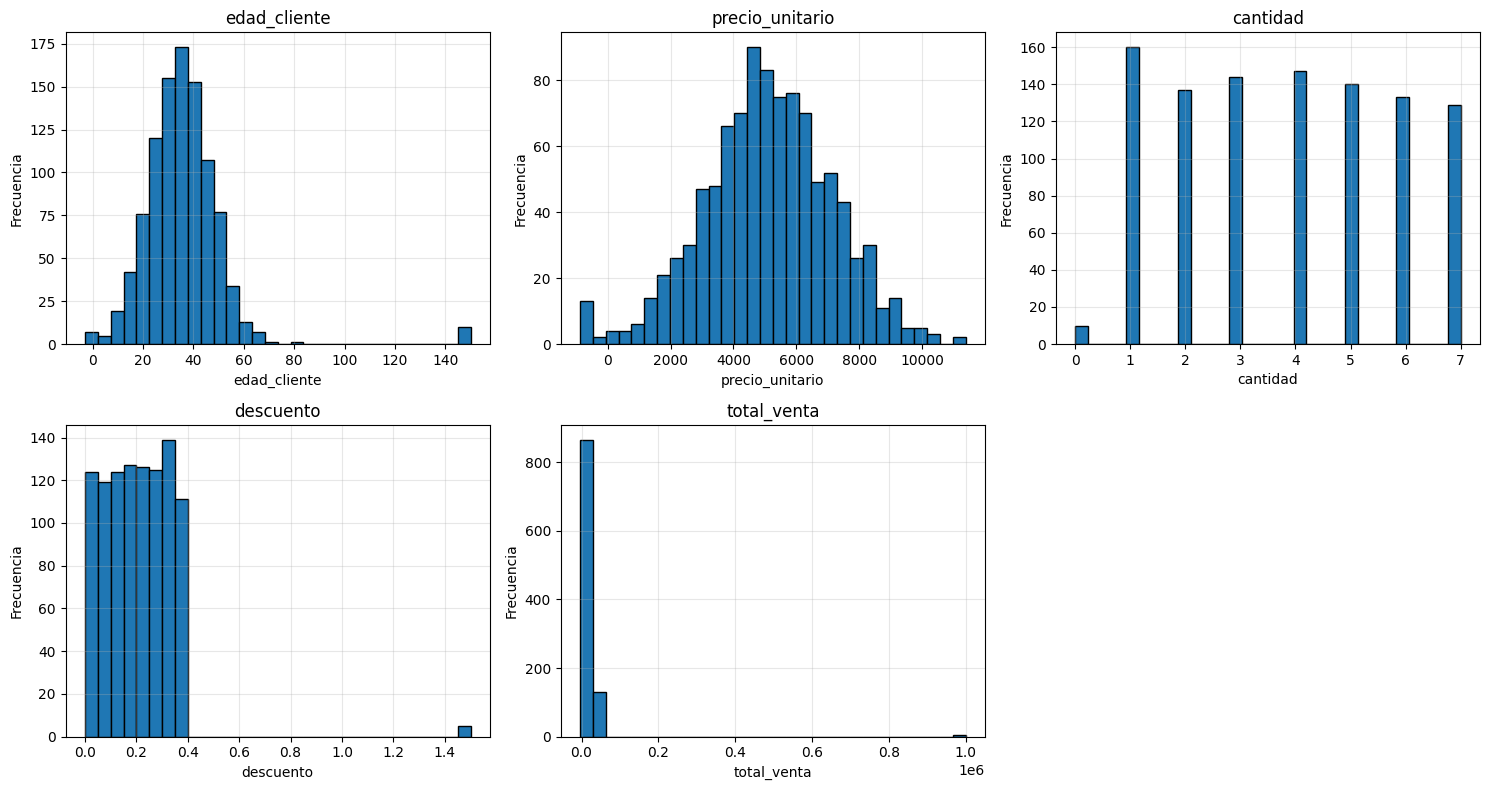

In [30]:
#Histogramas de las variables
variables = df.columns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, variable in enumerate(variables):
    axes[i].hist(df[variable].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(variable)
    axes[i].set_xlabel(variable)
    axes[i].set_ylabel("Frecuencia")
    axes[i].grid(alpha=0.3)

# Oculta el último subplot vacío
axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

Estos gráficos aportan Informacion muy util para cada variable:
- Edad_cliente: Se puede ver que la mayor concentración de observaciones se encuentra alrededor de los 30 años, pero, hay algunos valores aislados fuera de el rango de mayor concentración (20-50), y estos generan una cola a derecha.
- Precio_unitario: Vemos que se presenta una forma de campana centrada entre los 4.000 y 6.000 donde la mayor concentración de observaciones se encuentra justamente en ese rango, aun asi, hay una presencia de valores negativos, que distorsionan un poco el extremo izquierdo.
- Cantidad: En esta variable gráficamente no hay forma de campana, sin embargo resulta esperable pues se toman pocos valores enteros (0-7) aun asi hay una cantidad notable de valores nulos, que podrían interpretarse como una inconsistencia.
- Descuento: La mayoría de observaciones se presentan en un rango de 0.0 a 0.4 lo que tiene sentido, aun asi, hay unas pocas que se encuentra mas allá de 1.5, haciendo una cola bastante larga.
- Total_venta: De manera similar a descuento, la mayoría de observaciones están sobre el lado izquierdo del gráfico, estos se ven comprimidos por valores que se encuentran muy alejados sobre el lado derecho del gráfico.

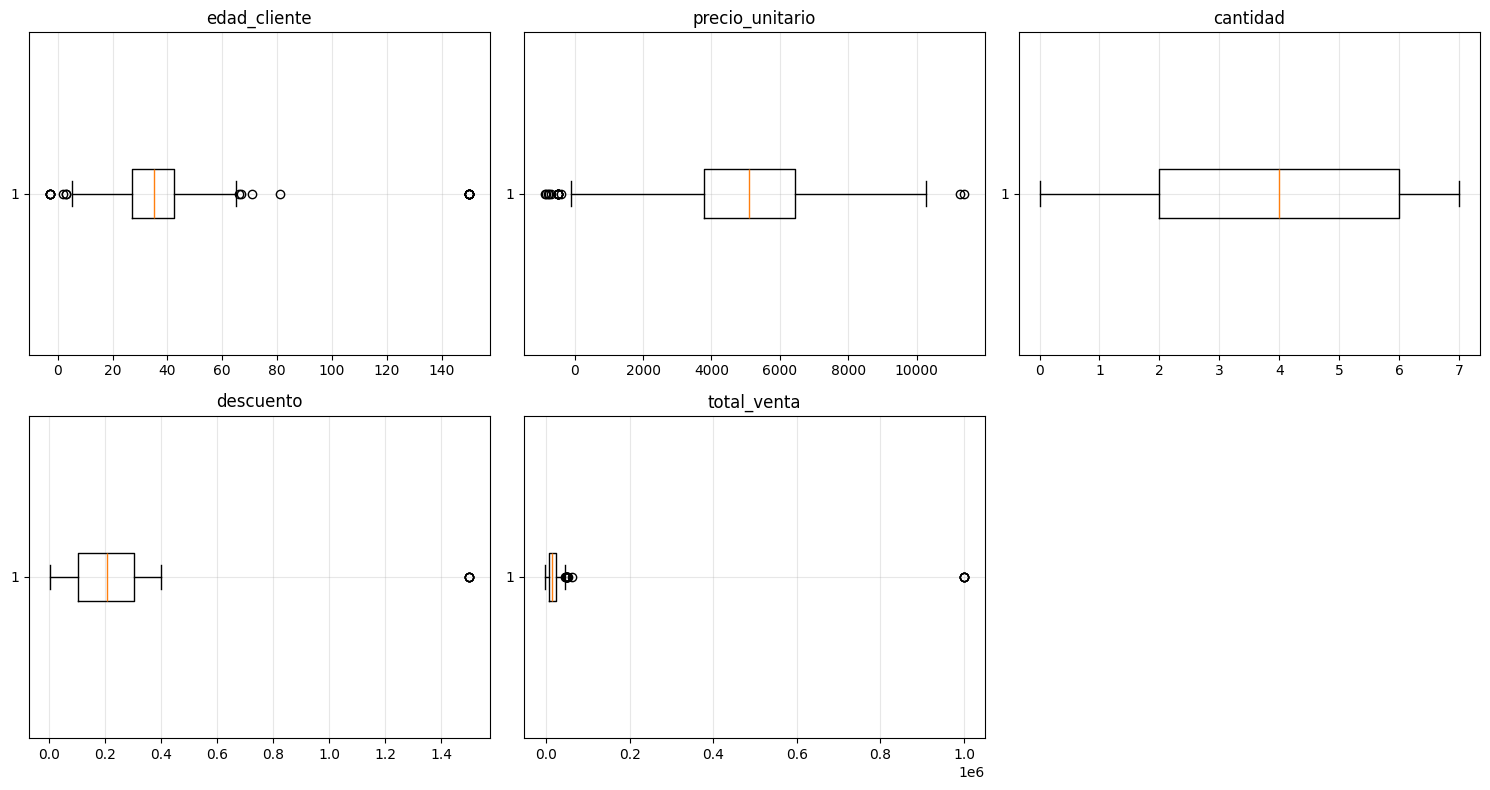

In [32]:
#Hacemos ahora Boxplots para ver la distribución de los datos y detectar posibles outliers de una mejor forma
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, variable in enumerate(variables):
    axes[i].boxplot(df[variable].dropna(), vert=False)
    axes[i].set_title(variable)
    axes[i].grid(alpha=0.3)

axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

Los diagramas de caja nos permiten visualizar la posición de la mediana, la dispersión de los datos y la presencia de valores atípicos en cada variable analizada.

- Edad del cliente: La mayor parte de las edades se concentra aproximadamente entre los 27 y 42 años, con una mediana cercana a los 35 años se pueden ver varios valores atípicos, inferiores y superiores, destacándose especialmente un registro de 150 años, claramente fuera del rango esperado.
- Precio unitario: La distribución presenta una dispersión moderada alrededor de la mediana, se observan algunos valores atípicos negativos, producto de precios inválidos, así como algunos valores elevados cercanos a los 11.000.
- Cantidad: No se observan valores atípicos. La totalidad de los registros se encuentra comprendida entre 1 y 7 unidades, lo cual resulta consistente.
- Descuento: La mayor parte de los descuentos se concentra entre 0,10 y 0,30, mientras que el valor correspondiente a 1,5 (150 %) aparece claramente identificado como un valor atípico.
- Total de venta: esta variable presenta la mayor cantidad de valores extremos, el registro de 1.000.000 se encuentra muy alejado del resto de las observaciones y comprime visualmente la distribución principal, evidenciando una fuerte presencia de outliers.

En términos generales, los diagramas de caja confirman las sospechas que el análisis descriptivo nos dejo, las variables edad_cliente, precio_unitario y especialmente total_venta, presentan valores atípicos bien identificables. Por otro lado, la variable cantidad no muestra outliers desde el punto de vista estadístico, aun asi, contiene valores 0 que forman parte de una inconsistencia desde el punto de vista de nuestro problema.

### **Detección de outliers**

Para llevar a cabo esta etapa utilizarizaremos el método de rango intercuartilico (RIC) consideraremos un outlier leve si x< $Q_1 - 1.5RIC$ o 
x > $Q_3 - 1.5RIC$ y un outlier extremo si x < $Q_1 - 3RIC$ o x > $Q_3 - 3RIC$ 

In [34]:
#Creamos un dataset nuevo con los outliers para ver la cantidad de outliers que hay en cada variable y los limites superior e inferior de cada una
resultado = []

for variable in df.columns:

    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    IQR = Q3 - Q1

    li = Q1 - 1.5*IQR
    ls = Q3 + 1.5*IQR

    cantidad = ((df[variable] < li) | (df[variable] > ls)).sum()

    resultado.append({
        "Variable": variable,
        "Límite inferior": li,
        "Límite superior": ls,
        "Outliers": cantidad
    })

pd.DataFrame(resultado)

,Variable,Límite inferior,Límite superior,Outliers
0,edad_cliente,4.125000,65.125000,23
1,precio_unitario,-215.705387,10430.073826,16
2,cantidad,-4.000000,12.000000,0
3,descuento,-0.193161,0.598307,5
4,total_venta,-16103.649331,45549.600745,17


A pesar de ya tener los aparentes outliers de manera gráfica con Boxplot, resulta util hacerlo también mediante un análisis cuantitativo, para ver todo de manera mas precisa y no solamente basarnos en lo que uno puede interpretar mediante un gráfico, a pesar de que esto ultimo sea un paso util también.

### **Análisis Bivariado**

Estudiaremos las relaciones o asociaciones que posean nuestras variables dos a dos gráficamente.

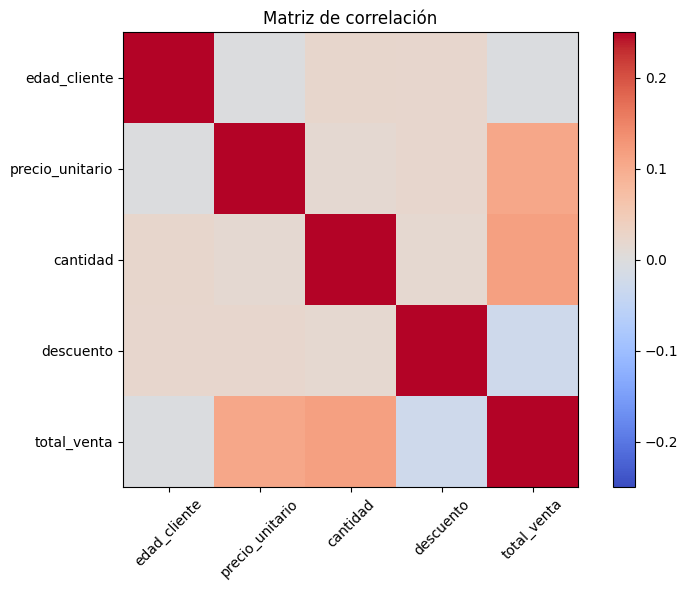

In [41]:
#Nos construimos una matriz de correlación para ver la relación entre las variables numéricas

#Calculamos el coeficiente de correlación de Pearson.
correlation = df.corr(numeric_only=True)

#Graficamos la matriz de correlación con un mapa de calor para visualizar mejor las relaciones entre las variables
plt.figure(figsize=(8,6))

plt.imshow(correlation, cmap="coolwarm", vmin=-0.25, vmax=0.25)

plt.colorbar()

plt.xticks(range(len(correlation.columns)),
           correlation.columns,
           rotation=45)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Matriz de correlación")

plt.tight_layout()
plt.show()

La matriz de correlación muestra una asociación positiva entre precio_unitario y total_venta, indicando que a medida que aumenta el precio unitario también tiende a aumentar el importe total de la venta, de manera similar, se observa una correlación positiva entre cantidad y total_venta, aunque de menor intensidad. Por otra parte, descuento presenta una correlación negativa con el total de la venta, lo cual resulta consistente con la forma en que se calcula dicha variable. Por ultimo, edad_cliente no muestra alguna correlación significativa con el resto de las variables, sugiriendo que su comportamiento es independiente dentro del conjunto de datos.

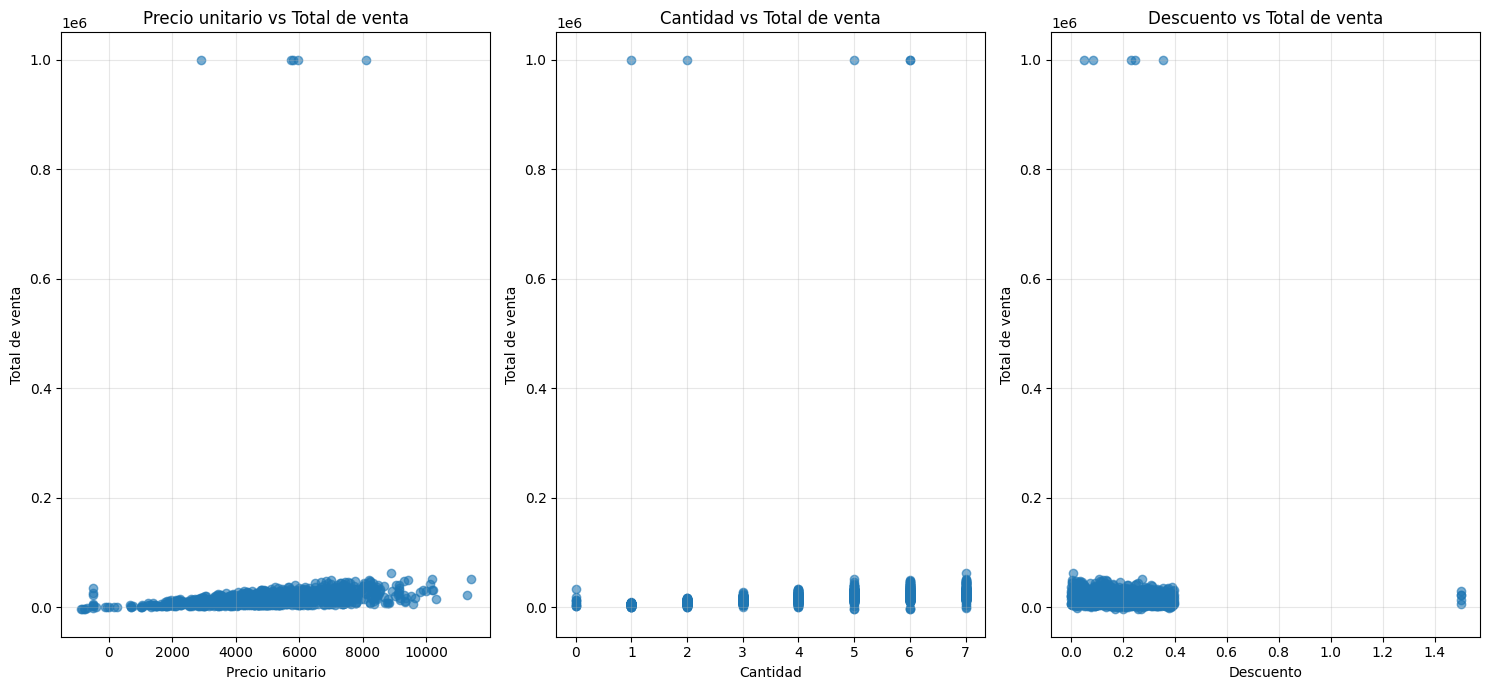

In [ ]:
#Hacemos ahora un grafico scatter para ver la relación entre las variables precio unitario, cantidad y descuento con respecto al total de venta

fig, axes = plt.subplots(1, 3, figsize=(15, 7))

# Precio unitario vs Total de venta
axes[0].scatter(df["precio_unitario"], df["total_venta"], alpha=0.6)
axes[0].set_title("Precio unitario vs Total de venta")
axes[0].set_xlabel("Precio unitario")
axes[0].set_ylabel("Total de venta")
axes[0].grid(alpha=0.3)

# Cantidad vs Total de venta
axes[1].scatter(df["cantidad"], df["total_venta"], alpha=0.6)
axes[1].set_title("Cantidad vs Total de venta")
axes[1].set_xlabel("Cantidad")
axes[1].set_ylabel("Total de venta")
axes[1].grid(alpha=0.3)

# Descuento vs Total de venta
axes[2].scatter(df["descuento"], df["total_venta"], alpha=0.6)
axes[2].set_title("Descuento vs Total de venta")
axes[2].set_xlabel("Descuento")
axes[2].set_ylabel("Total de venta")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Con fines visuales y haremos una segunda representación de los diagramas de dispersión, pero esta vez sin los valores atípicos extremos ya que comprimen el gráfico e impiden visualizar de forma cómoda la relación entre las variables.

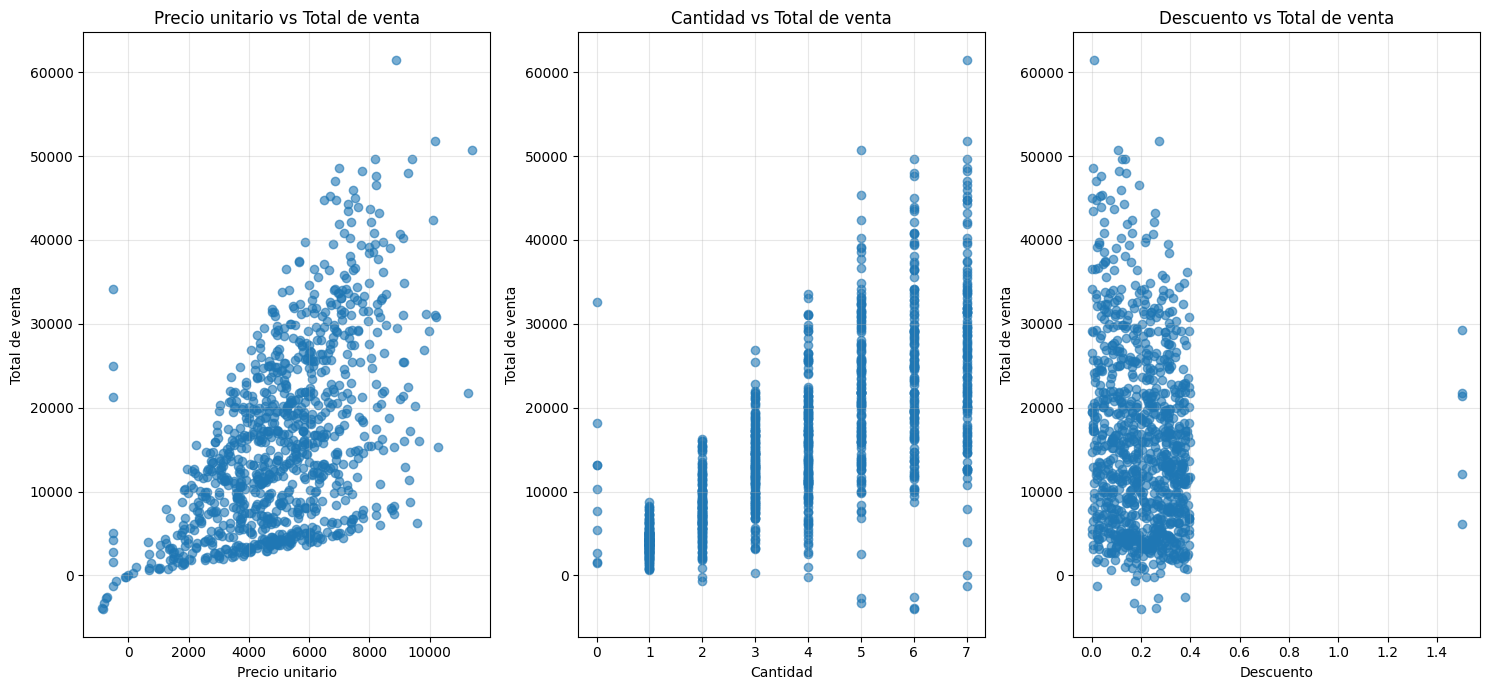

In [46]:
#Hacemos ahora un grafico scatter esta vez con la variable total_venta sin los outliers

df_grafico = df[df['total_venta'] < 100000 ]

fig, axes = plt.subplots(1, 3, figsize=(15, 7))

# Precio unitario vs Total de venta
axes[0].scatter(df_grafico["precio_unitario"], df_grafico["total_venta"], alpha=0.6)
axes[0].set_title("Precio unitario vs Total de venta")
axes[0].set_xlabel("Precio unitario")
axes[0].set_ylabel("Total de venta")
axes[0].grid(alpha=0.3)

# Cantidad vs Total de venta
axes[1].scatter(df_grafico["cantidad"], df_grafico["total_venta"], alpha=0.6)
axes[1].set_title("Cantidad vs Total de venta")
axes[1].set_xlabel("Cantidad")
axes[1].set_ylabel("Total de venta")
axes[1].grid(alpha=0.3)

# Descuento vs Total de venta
axes[2].scatter(df_grafico["descuento"], df_grafico["total_venta"], alpha=0.6)
axes[2].set_title("Descuento vs Total de venta")
axes[2].set_xlabel("Descuento")
axes[2].set_ylabel("Total de venta")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Los diagramas de dispersión muestran una relación positiva entre el precio unitario y el total de la venta, así como entre la cantidad de productos y el importe total. En cambio, la relación entre el descuento y el total de la venta es menos evidente, debido a que esta variable también depende del precio unitario y de la cantidad adquirida. Asimismo, en los tres gráficos se observaba la presencia de valores atípicos extremos correspondientes a ventas de un millón de pesos, los cuales comprimían visualmente la nube principal de observaciones.

---

---

## ***Limpieza de datos***

En esta etapa, nos dedicaremos a tratar los errores que fueron encontrados durante EDA: Valores faltantes, corrección de valores fuera de rango y tratamiento de outliers.

### **Tratamiento de valores faltantes**

En nuestro caso fueron detectados valores faltantes en precio_unitario entonces:

In [50]:
#Llenamos los valores faltantes de la variable precio_unitario con la mediana de la misma.
df["precio_unitario"] = df["precio_unitario"].fillna(df["precio_unitario"].median())

#Verificamos si se han llenado los valores faltantes
print("\nValores faltantes por columna después de llenar los valores faltantes:")
print(df.isnull().sum())


Valores faltantes por columna después de llenar los valores faltantes:
edad_cliente       0
precio_unitario    0
cantidad           0
descuento          0
total_venta        0
dtype: int64


Decidimos utilizar la mediana pare rellenar esos valores faltantes pues esta es mas robusta que la media frente a valores atípicos.

### **Corrección de valores fuera de rango**

In [52]:
#Eliminamos las edades negativas y mayores a 100, y nos quedamos con mayores de edad
df = df[(df["edad_cliente"] >= 18) & (df["edad_cliente"] <= 100)]

#Eliminamos precios negativos
df = df[df["precio_unitario"] >= 0]

#Cantidades menores o iguales a 0
df = df[df["cantidad"] > 0]

#Mantenemos descuentos entre 0 y 1
df = df[(df["descuento"] >= 0) & (df["descuento"] < 1)]

Mantenemos las edades considerándolas a partir de lo que son adultos jóvenes, nos deshacemos de los precios unitarios negativos y cantidades nulas o negativas también, y consideramos descuentos de [0,1) sin considerar el 1 pues eso conlleva un 100% de descuento que no es algo común.

### **Tratamiento de outliers**

Usaremos IQR, creamos una función para no repetir código y la utilizamos con cada variable

In [53]:
#Creamos la función eliminar_outliers para ahorrarnos repetir mucho código.
def eliminar_outliers(df, columna):

    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)

    IQR = Q3 - Q1

    li = Q1 - 1.5 * IQR
    ls = Q3 + 1.5 * IQR

    return df[(df[columna] >= li) & (df[columna] <= ls)]

#Eliminamos los outliers de las variables edad_cliente, precio_unitario, descuento y total_venta
for columna in [
    "edad_cliente",
    "precio_unitario",
    "descuento",
    "total_venta"
]:
    df = eliminar_outliers(df, columna)

### **Verificación final**

Verificamos si la limpieza funciono

In [55]:
#Informacion general del dataset después de la limpieza
print("\nInformacion del dataset después de la limpieza:")
print(df.info())

#Resumen estadístico del dataset después de la limpieza
print("\nResumen estadístico del dataset después de la limpieza:")
print(df.describe())  

#Valores nulos del dataset después de la limpieza
print("\nValores faltantes por columna después de la limpieza:")
print(df.isnull().sum())

#Valores duplicados del dataset después de la limpieza
print("\nValores duplicados después de la limpieza:")
print(df.duplicated().sum())


Informacion del dataset después de la limpieza:
<class 'pandas.DataFrame'>
Index: 865 entries, 0 to 999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   edad_cliente     865 non-null    int64  
 1   precio_unitario  865 non-null    float64
 2   cantidad         865 non-null    int32  
 3   descuento        865 non-null    float64
 4   total_venta      865 non-null    float64
dtypes: float64(3), int32(1), int64(1)
memory usage: 37.2 KB
None

Resumen estadístico del dataset después de la limpieza:
       edad_cliente  precio_unitario    cantidad   descuento   total_venta
count    865.000000       865.000000  865.000000  865.000000    865.000000
mean      36.391908      5129.795645    3.840462    0.200170  15626.920128
std       10.142625      1838.726252    1.995360    0.114112  10103.777369
min       18.000000       151.519479    1.000000    0.000539    328.077616
25%       28.000000      3885.016430    2.0

Por ultimo vemos gráficamente como ha mejorado.

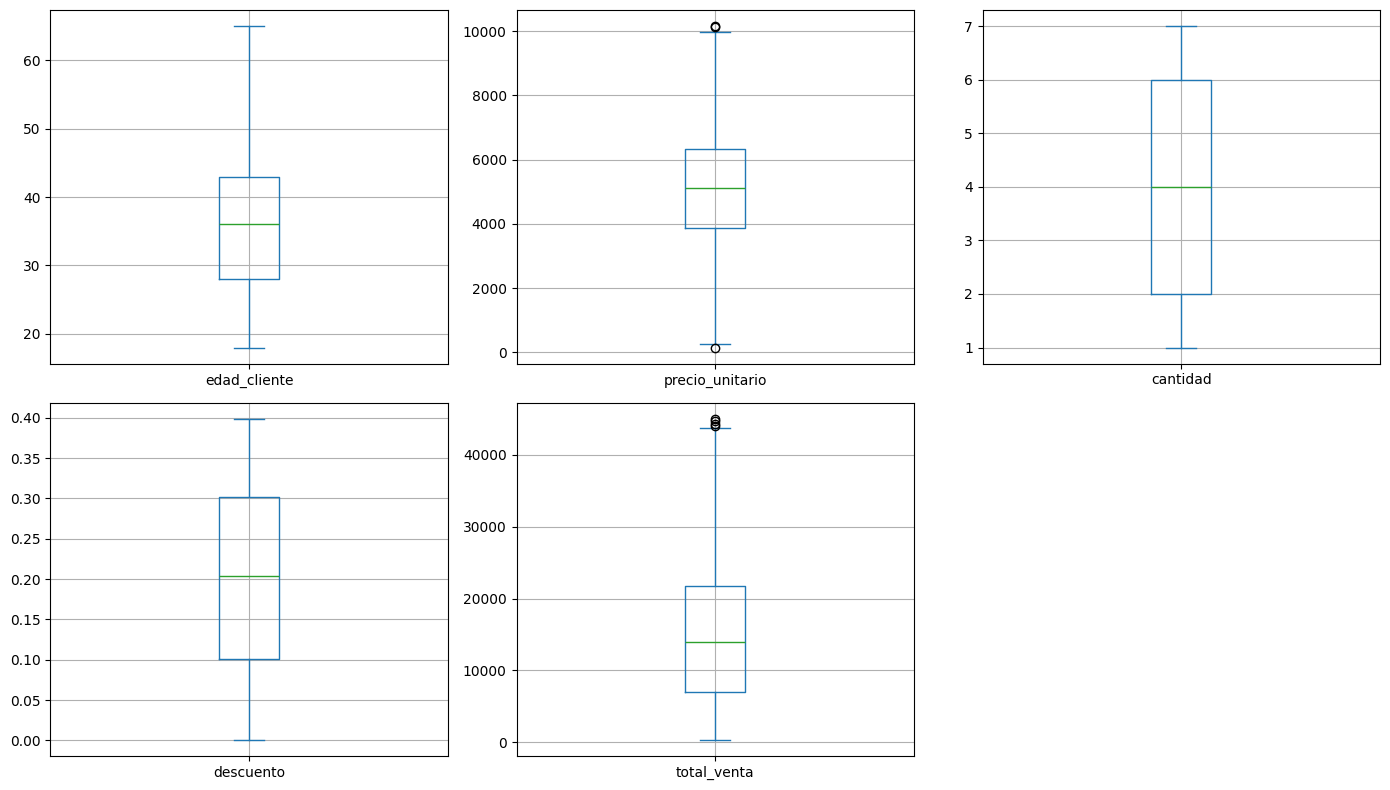

In [56]:
#Hacemos ahora Boxplots para ver la distribución de los datos después de la limpieza
df.plot(
    kind="box",
    subplots=True,
    layout=(2,3),
    figsize=(14,8),
    grid=True
)

plt.tight_layout()
plt.show()

Luego del tratamiento de valores faltantes, la eliminación de registros con valores fuera de rango y la aplicación del criterio del rango intercuartílico, el conjunto de datos presenta una distribución más consistente. Si bien permanecen algunas observaciones identificadas como atípicas, estas pueden corresponder a valores extremos pero plausibles y no afectan significativamente la calidad general del conjunto de datos.

---

---

## ***Conclusiones***

En este trabajo se llevó a cabo un Análisis Exploratorio de Datos (EDA) sobre un conjunto de datos sintético de ventas, diseñado con el propósito de incluir valores faltantes, registros fuera de rango y valores atípicos para simular situaciones habituales.

Para empezar, se realizó una inspección general del conjunto de datos, verificando su estructura, dimensiones, tipos de datos y la existencia de valores faltantes, luego, mediante el análisis descriptivo univariado se obtuvieron medidas y dispersiones que permitieron identificar primeras inconsistencias, como edades imposibles, precios negativos y descuentos superiores al rango permitido.

El análisis de distribuciones, complementado con histogramas y diagramas de caja, permitió estudiar el comportamiento de cada variable y confirmar visualmente la presencia de valores atípicos. Seguido de este, el análisis bivariado, apoyado en la matriz de correlación y los diagramas de dispersión, permitió evaluar las relaciones entre las variables numéricas. Se observó una asociación positiva entre el precio unitario y el total de la venta, así como entre la cantidad de productos y el importe total, mientras que el descuento mostró una relación negativa menos marcada.

Por ultimo, se llevó a cabo una etapa de limpieza de datos que incluyó el tratamiento de valores faltantes imputando con la mediana, la eliminación de registros con valores fuera de los rangos válidos y el tratamiento de valores atípicos utilizando criterio del rango intercuartílico (IQR). La verificación posterior confirmó que el conjunto de datos resultante presenta una estructura consistente y adecuada para futuras tareas de análisis o modelado.